## Introduction

This is the map for day 3 of the 30DayMapChallenge with the topic "Polygons". For this day, I decided to map the biogeographic regions for India.

I obtained the data from the [India Biodiversity Portal](https://indiabiodiversity.org/map?layers=) and more specifically, I used the India Biogeographic Zones. The data were downloaded from the portal and uploaded in Google Colab and processed in Geopandas. Also, the package contextily was used for basemaps.

This code differs from the code that I used in the 3-DayMapChallenge as I found that for some of my colours they looked similar among different categories. The competition goes at a very fast pace so I just submitted the map very fast.

I used the colours of the colours of the tab20b theme of matplotlib as an example but I have commented out the actual (lighter) colours that I used in the 30DayMapChallenge (so you can try it if you like).

In this code, I also experimented with creating a custom legend below the map. This is the first time I have been using this.

In [1]:
!pip install contextily --quiet

In [2]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [3]:
df = gpd.read_file('/content/lyr_76_india_biogeographic.shp')

<Axes: >

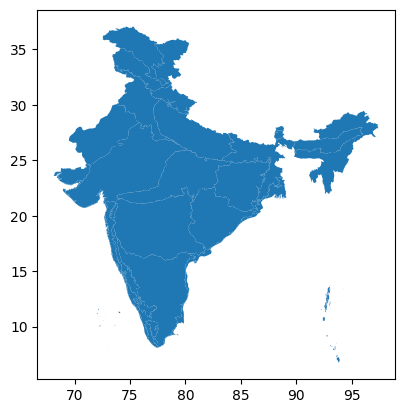

In [4]:
df.plot()

In [5]:
df.head()

,__mlocate_,__mlocate0,__mlocate1,__mlocate2,__mlocate3,__mlocate4,__mlocate5,__mlocate6,__mlocate7,__mlocate8,prov_code,biogeozone,biogeoprov,zone_code,area_sqkm,geometry
0,174675.0,156.0,1,0.0,1.0,2009-02-16,1.0,2009-02-16,1.0,2009-02-16,10A,Islands,Islands: Andamans,10,5398.78,"MULTIPOLYGON (((92.59024 10.76183, 92.5889 10...."
1,174676.0,156.0,1,0.0,1.0,2009-02-16,1.0,2009-02-16,1.0,2009-02-16,10B,Islands,Islands: Nicobars,10,1732.88,"MULTIPOLYGON (((93.70412 7.20921, 93.69917 7.2..."
2,174677.0,156.0,1,0.0,1.0,2009-02-16,1.0,2009-02-16,1.0,2009-02-16,1A,Trans-Himalaya,Trans-Himalaya: Ladakh Mountains,1,109642.65,"POLYGON ((74.73447 37.01609, 74.73643 37.01478..."
3,174678.0,156.0,1,0.0,1.0,2009-02-16,1.0,2009-02-16,1.0,2009-02-16,1B,Trans-Himalaya,Trans-Himalaya: Tibetan Plateau,1,75168.98,"MULTIPOLYGON (((88.65383 28.09467, 88.66267 28..."
4,174679.0,156.0,1,0.0,1.0,2009-02-16,1.0,2009-02-16,1.0,2009-02-16,2A,Himalaya,Himalaya: North West,2,70056.86,"POLYGON ((74.54039 35.069, 74.58207 35.019, 74..."


Checking the types in the Geopandas dataframe

Only keeping the relevant columns:

In [9]:
df = df.loc[:, ['biogeozone', 'geometry']]
## df.head()

In [10]:
print(df['biogeozone'].unique())

['Islands' 'Trans-Himalaya' 'Himalaya' 'Desert' 'Semi-Arid'
 'Western Ghats' 'Deccan Peninsula' 'Gangetic Plain' 'Coasts' 'North-East']


In [11]:
print(f'There are {len(df['biogeozone'].unique())} different biogeographic zones in India')

There are 10 different biogeographic zones in India


In [13]:
df.crs

In [14]:
df = df.set_crs('epsg:4326')

In [15]:
df = df.to_crs(epsg=3857)

Create a map with custom colours:

In [17]:
# These colors actualy match part of the colours of the tab20b colour palette
# but I "hand picked" them here.
custom_colors = ['#393b79', '#6b6ecf', '#637939', '#b5cf6b', '#8c6d31', '#e7cb94', '#ad494a', '#e7969c', '#a55194', '#de9ed6']

The following colours I actually used in the map challenge but the colour selection was anything but good 😀

In [18]:
# https://towardsdatascience.com/customize-colormaps-with-matplotlib-df5b37d14662/

# custom_colors = [
#     '#fbb4ae', '#b3cde3', '#fddaec', '#ccebc5',
#     '#fed9a6', '#ffffcc', '#e5d8bd', '#decbe4',
#     '#d9f0f0', '#f2f2f2'
# ]

In [19]:
# Create a ListedColormap (discrete colors):
custom_cmap_discrete = ListedColormap(custom_colors)

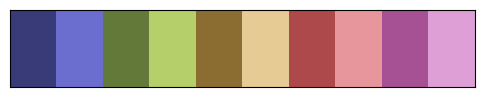

In [20]:
# Display the color map - code from:
# https://towardsdatascience.com/customize-colormaps-with-matplotlib-df5b37d14662/
fig, ax = plt.subplots(figsize=(6, 1))
plt.imshow([[i for i in range(len(custom_colors))]],
           cmap=custom_cmap_discrete,
           aspect='auto')
plt.xticks([]), plt.yticks([]);
# plt.show()

Imagine now we want to custom the colors. As an example, I will take the colors of

In [21]:
df['biogeozone'].unique()

array(['Islands', 'Trans-Himalaya', 'Himalaya', 'Desert', 'Semi-Arid',
       'Western Ghats', 'Deccan Peninsula', 'Gangetic Plain', 'Coasts',
       'North-East'], dtype=object)

Add the default legend to the map

Get the list with the names:

In [23]:
zones = (df['biogeozone'].unique())
zones

array(['Islands', 'Trans-Himalaya', 'Himalaya', 'Desert', 'Semi-Arid',
       'Western Ghats', 'Deccan Peninsula', 'Gangetic Plain', 'Coasts',
       'North-East'], dtype=object)

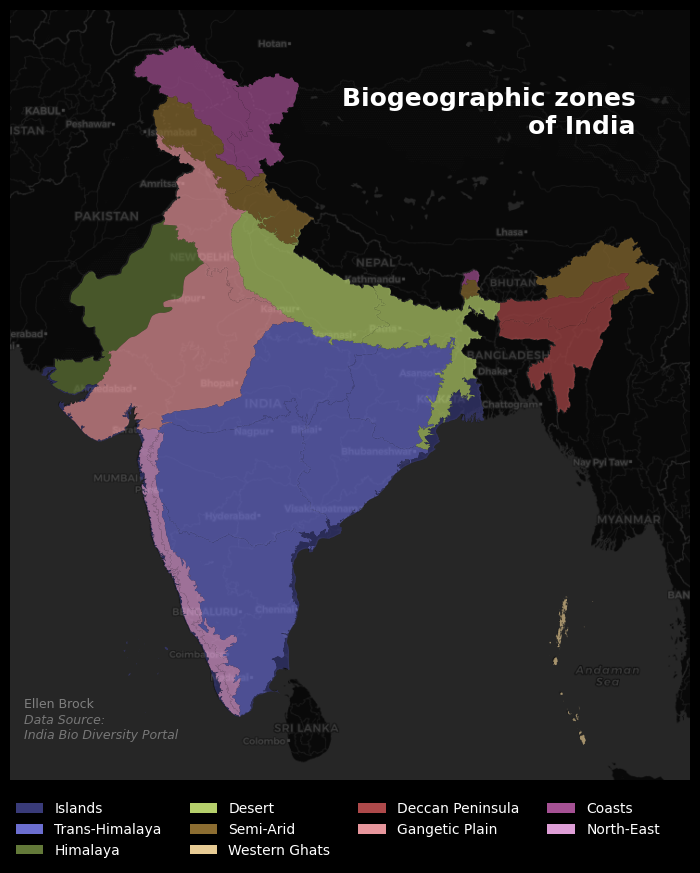

In [28]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
df.plot(
    ax = ax,
    column = 'biogeozone',
    categorical = True,
    legend = False, # Set this true as we will create a custom legend and needs to grab the elements
    alpha = 0.7,
    cmap = custom_cmap_discrete,
    edgecolor = 'none')

ctx.add_basemap(
    ax,
    crs=df.crs,
    source=ctx.providers.CartoDB.DarkMatter,
    attribution=False,
)

handles = [Patch(facecolor=custom_colors[i], edgecolor='none', label=str(label)) for i, label in enumerate(zones)]

ax.legend(
    handles=handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    bbox_transform=fig.transFigure,
    fontsize=10,
    title_fontsize=11,
    labelcolor='white'
)


ax.text(
    0.92, 0.9,
    "Biogeographic zones\nof India",
    transform=ax.transAxes,
    fontsize=18,
    color='white',
    ha='right', va='top',
    fontweight='bold',

)


ax.text(
    0.02, 0.09,
    "Ellen Brock",
    transform=ax.transAxes,
    fontsize=9,
    color='grey',
    ha='left', va='bottom'
)

ax.text(
    0.02, 0.05,
    "Data Source:\nIndia Bio Diversity Portal",
    transform=ax.transAxes,
    fontsize=9,
    color='grey',
    ha='left', va='bottom',
    fontstyle='italic',
    alpha=0.9
)


ax.axis('off')

plt.savefig(
    "biogeographic_zones_india_dark.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


## References

https://geopandas.org/en/stable/gallery/plotting_basemap_background.html

https://towardsdatascience.com/customize-colormaps-with-matplotlib-df5b37d14662/

https://www.geeksforgeeks.org/python/matplotlib-axes-axes-text-in-python/

https://matplotlib.org/stable/users/explain/axes/legend_guide.html

https://python-graph-gallery.com/custom-legend-with-matplotlib/

https://andrewpwheeler.com/2022/09/16/legends-in-python/